In [1]:
import glob
import numpy as np 
import os
import matplotlib.pyplot as plt
from utils import *

In [2]:
matched_gids = np.load('matched_primary_sc0_gids_kn1S-R1-DF_z0.0.npy')

In [3]:
matched_gids

array([( 6515,  8895, 0.84874305,  3.82574701),
       ( 7533,  7704, 0.82389466, 16.42470169),
       ( 9098,  7780, 0.83299579,  2.18416715), ...,
       ( 9746,  9896, 0.828147  , 13.71356201),
       ( 7172,  7304, 0.78575861,  3.1962676 ),
       (11115, 12260, 0.81908111, 11.61530972)],
      dtype=[('GroupID1', '<u8'), ('GroupID2', '<u8'), ('Merit', '<f8'), ('Distance', '<f8')])

In [4]:
matched_gids.shape

(3169,)

In [5]:
# compare KE of these halos in two sims, only z=0 for now
# load data
zs = [0.0]
sim_names = ['kn1S-Repos1', 'kn1S-DF']

# include both BHs that released and not released KE

kbh_SRepos1 = get_kBH_end_zs(sim_names[0], zs, halo_info=True, released_only=False)[0.0]
kbh_SDF = get_kBH_end_zs(sim_names[1], zs, halo_info=True, released_only=False)[0.0]


Updating FirstReleaseTime of BHID 307586876 from 0.1968031495970948 to 0.19410616262585903 (from swallowed BHID 309616953)
Updating FirstReleaseTime of BHID 307968319 from 0.2050688202213354 to 0.19410616262585903 (from swallowed BHID 307586876)
Updating FirstReleaseTime of BHID 310834883 from 0.2091737053731065 to 0.19410616262585903 (from swallowed BHID 307968319)
Updating FirstReleaseTime of BHID 303496014 from 0.2218795141358581 to 0.19410616262585903 (from swallowed BHID 310834883)
Updating FirstReleaseTime of BHID 275407802 from 0.22448297131277567 to 0.21502742445066797 (from swallowed BHID 282397259)
Updating FirstReleaseTime of BHID 286484337 from 0.22490294833270763 to 0.21502742445066797 (from swallowed BHID 275407802)
Updating FirstReleaseTime of BHID 303496644 from 0.22707993753979575 to 0.19410616262585903 (from swallowed BHID 303496014)
Updating FirstReleaseTime of BHID 288116913 from 0.2283239998653931 to 0.21502742445066797 (from swallowed BHID 286484337)
Updating Firs

In [6]:
# extract only those in matched_gids
kbh_SRepos1_matched = {}
mask_matched = np.isin(kbh_SRepos1['GroupID'], matched_gids['GroupID1'])
for key in kbh_SRepos1:
    kbh_SRepos1_matched[key] = kbh_SRepos1[key][mask_matched]

kbh_SDF_matched = {}
mask_matched = np.isin(kbh_SDF['GroupID'], matched_gids['GroupID2'])
for key in kbh_SDF:
    kbh_SDF_matched[key] = kbh_SDF[key][mask_matched]

In [7]:
kbh_SRepos1_matched

{'BHID': array([262255953, 262301750, 262323473, ..., 523692814, 523933840,
        524152835], dtype=uint64),
 'BHMass': array([ 599437.32793911, 2305690.73302088,  353939.91880344, ...,
        2449473.7138277 ,   34738.89585944, 2233758.78139433]),
 'FirstReleaseTime': array([-1., -1., -1., ..., -1., -1., -1.]),
 'FirstReleaseMass': array([-1.e+10, -1.e+10, -1.e+10, ..., -1.e+10, -1.e+10, -1.e+10]),
 'ReleasedKE': array([0., 0., 0., ..., 0., 0., 0.]),
 'EndTime': array([1., 1., 1., ..., 1., 1., 1.]),
 'SwallowID': array([18446744073709551615, 18446744073709551615, 18446744073709551615,
        ..., 18446744073709551615, 18446744073709551615,
        18446744073709551615], dtype=uint64),
 'GroupID': array([ 7890,  6515,  7145, ...,  9746,  7172, 11115]),
 'GroupMass': array([4.73327002e+10, 4.58195845e+10, 4.69632287e+10, ...,
        2.52452823e+10, 4.27099218e+10, 2.29323858e+10]),
 'M200c': array([2.05809069e+10, 3.99343729e+10, 1.29656398e+10, ...,
        2.14105034e+10, 2.95532

In [8]:
kbh_SRepos1_matched['ReleasedKE'].min(), kbh_SRepos1_matched['ReleasedKE'].max()

(0.0, 2043.2443607523492)

In [9]:
kbh_SDF_matched['ReleasedKE'].min(), kbh_SDF_matched['ReleasedKE'].max()

(0.0, 1884.3362104800349)

In [10]:
kbh_SRepos1_matched['ReleasedKE'].sum()

14682.378090022115

In [11]:
kbh_SDF_matched['ReleasedKE'].sum()

9892.766923567304

In [12]:
print(f'{kbh_SRepos1_matched["BHMass"].sum():.4e} Msun/h in kn1S-Repos1')

9.9043e+09 Msun/h in kn1S-Repos1


In [13]:
print(f'{kbh_SDF_matched["BHMass"].sum():.4e} Msun/h in kn1S-DF')

1.0688e+10 Msun/h in kn1S-DF


In [14]:
np.log10(kbh_SRepos1_matched['M200c'].max()), np.log10(kbh_SRepos1_matched['M200c'].min())

(11.307634901198979, 9.889530928218615)

In [15]:
np.log10(kbh_SDF_matched['M200c'].max()), np.log10(kbh_SDF_matched['M200c'].min())

(11.296932297316944, 9.844146902850367)

/var/folders/f2/_m97yrqd1x383mz_47xpv__w0000gn/T/ipykernel_85205/384019527.py:7: RuntimeWarning: divide by zero encountered in log10
  np.log10(kbh_SRepos1_matched['ReleasedKE']).max(),
/var/folders/f2/_m97yrqd1x383mz_47xpv__w0000gn/T/ipykernel_85205/384019527.py:8: RuntimeWarning: divide by zero encountered in log10
  np.log10(kbh_SDF_matched['ReleasedKE']).max()
/var/folders/f2/_m97yrqd1x383mz_47xpv__w0000gn/T/ipykernel_85205/384019527.py:29: RuntimeWarning: divide by zero encountered in log10
  sc = ax.scatter(np.log10(m_halo), np.log10(m_bh), c=np.log10(ke), cmap='hot', s=50, edgecolor='k', alpha=0.7)


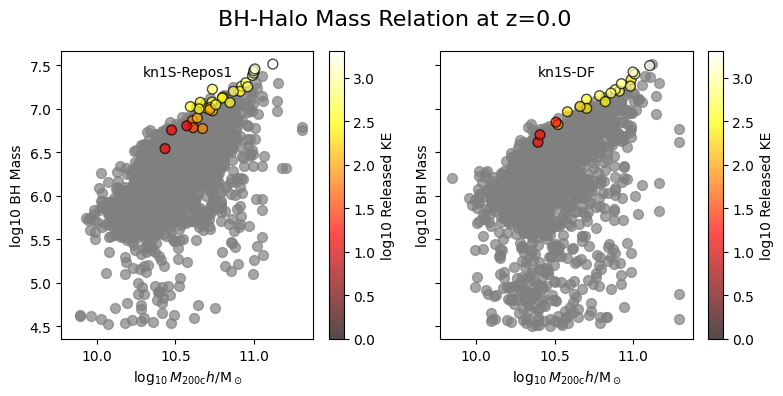

In [16]:
# plot for z = 0

z = 0.0

# max KE across all simulations at z=0
lg_KE_max = max(
    np.log10(kbh_SRepos1_matched['ReleasedKE']).max(),
    np.log10(kbh_SDF_matched['ReleasedKE']).max()
)

fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

axs = axs.flatten()

bhs = [kbh_SRepos1_matched, kbh_SDF_matched]

def scatter_bhhalo(ax, bh_data, sim_name, clower=0, cupper=None):
    m_halo = bh_data['M200c']
    m_bh = bh_data['BHMass']
    ke = bh_data['ReleasedKE']

    # no release only
    k_mask = ke > 0
    nkm_halo = m_halo[~k_mask]
    nkm_bh = m_bh[~k_mask]
    nkke = ke[~k_mask]
    sc2 = ax.scatter(np.log10(nkm_halo), np.log10(nkm_bh), c='gray', s=50, edgecolor='gray', alpha=0.7)

    sc = ax.scatter(np.log10(m_halo), np.log10(m_bh), c=np.log10(ke), cmap='hot', s=50, edgecolor='k', alpha=0.7)
    sc.set_clim(clower, cupper)
    cb = plt.colorbar(sc, ax=ax)
    cb.set_label('log10 Released KE')
    ax.set_xlabel(r'$\log_{10} {M_\mathrm{200c}h/\mathrm{M}_\odot}$')
    ax.set_ylabel('log10 BH Mass')
    # ax.set_title(f'BH-Halo Mass Relation at z={z} ({sim_name})')
    # text instead of title
    ax.text(0.5, 0.95, f'{sim_name}',
            transform=ax.transAxes, ha='center', va='top')

for i, sim_name in enumerate(sim_names):
    scatter_bhhalo(axs[i], bhs[i], sim_name, clower=0, cupper=lg_KE_max)

# title
fig.suptitle(f'BH-Halo Mass Relation at z={z}', fontsize=16)

# tight layout
plt.tight_layout()


In [17]:
# find the halo pairs that have KE released in either sim

# gids1_ke = []
# gids2_ke = []

mask1 = kbh_SRepos1_matched['ReleasedKE'] > 0
gids1_ke = kbh_SRepos1_matched['GroupID'][mask1]
# unique
gids1_ke = np.unique(gids1_ke)

mask2 = kbh_SDF_matched['ReleasedKE'] > 0
gids2_ke = kbh_SDF_matched['GroupID'][mask2]
# unique
gids2_ke = np.unique(gids2_ke)

# gid pairs that have KE released in either sim
gids_ke_pairs = matched_gids[
    (np.isin(matched_gids['GroupID1'], gids1_ke)) |
    (np.isin(matched_gids['GroupID2'], gids2_ke))
]

# save the gid pairs
np.save('matched_primary_sc0_gids_kn1S-R1-DF_z0.0_KEonly.npy', gids_ke_pairs)

In [18]:
gids_ke_pairs.shape

(38,)

In [21]:
# find the group pair with highest KE released

max_ke_idx1 = np.argmax(kbh_SRepos1_matched['ReleasedKE'])
max_ke_gid1 = kbh_SRepos1_matched['GroupID'][max_ke_idx1]
max_ke_value1 = kbh_SRepos1_matched['ReleasedKE'][max_ke_idx1]

max_ke_idx2 = np.argmax(kbh_SDF_matched['ReleasedKE'])
max_ke_gid2 = kbh_SDF_matched['GroupID'][max_ke_idx2]
max_ke_value2 = kbh_SDF_matched['ReleasedKE'][max_ke_idx2]

print("kn1S-Repos1 max KE:")
print(f'GroupID: {max_ke_gid1}, ReleasedKE: {max_ke_value1:.4e}')
print("kn1S-DF max KE:")
print(f'GroupID: {max_ke_gid2}, ReleasedKE: {max_ke_value2:.4e}')

kn1S-Repos1 max KE:
GroupID: 2763, ReleasedKE: 2.0432e+03
kn1S-DF max KE:
GroupID: 3081, ReleasedKE: 1.8843e+03


In [22]:
gids_ke_pairs

array([( 4095,  4378, 0.80030968, 28.0742321 ),
       ( 9497, 10557, 0.72564882, 75.8459549 ),
       ( 4197,  4303, 0.55711277, 95.6750412 ),
       ( 6507,  6375, 0.88368955, 22.85803795),
       ( 5941,  4780, 0.85020771, 10.52462673),
       ( 6344,  6095, 0.87398119, 10.18835068),
       ( 4452,  5698, 0.81829334, 18.96313286),
       ( 3627,  3937, 0.82515243, 17.59408379),
       ( 5727,  5075, 0.8436879 , 38.67150116),
       ( 6212,  5433, 0.8712793 ,  4.94061708),
       ( 3090,  3199, 0.86522747, 18.03500366),
       ( 3964,  4397, 0.84845672, 21.39635658),
       (10031,  8932, 0.79088301,  7.47972345),
       ( 2763,  3081, 0.84762279, 38.84077835),
       ( 7556,  7439, 0.80878097, 19.81544304),
       ( 6853,  6678, 0.86750055,  7.17801332),
       (10816, 12307, 0.67473472, 49.85658646),
       ( 5476,  4928, 0.88816557,  8.8288269 ),
       ( 3677,  3910, 0.85005421, 14.45744514),
       ( 4784,  4943, 0.80362697,  8.8265152 ),
       ( 5111,  4866, 0.84976503, 19.816